In [ ]:
import wandb
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- User-configurable section ---
ENTITY = "faisal-ahmed-a-m"
PROJECT = "crl_rnn_craftax_classic_bug_fixed_finalr"
# ---------------------------------
game_name = ["Craftax-Classic-Symbolic-v1"]
int_rew_sources=["crl_ppo_rnn"]
for int_rew_source in int_rew_sources:
    for env_id in game_name:
        if int_rew_source == "TDD":
            run_configs = {
                "game_name": env_id,
                "int_rew_source":int_rew_source,
            }
        elif int_rew_source == "CTEC":
            run_configs = {
                "game_name": env_id,
                "int_rew_source":int_rew_source,
                "discount": 0.99,
                "ctec_energy_fn": "l1",
                "normalize_repr": 0
            }

        file_name = f"{env_id}_{int_rew_source}"
        if not os.path.exists(f"{file_name}.csv"):
            api = wandb.Api()
            runs = api.runs(f"{ENTITY}/{PROJECT}")
            all_data = []
            for run in runs:
                try:
                    # print(f"Processing run: {run.name}")
                    history = run.history()  # auto-sampled, might be sparse

                    # Optional: sort by 'global_step' or '_step' if available
                    step_col = "time/total_timesteps"
                    history = history.sort_values(step_col)
                    configs_ = [run.config[c] for c in run_configs]
                    # print(history["charts/episodic_return"])
                    print(configs_)
                    # include runs that satisfies the run_configs
                    include = True
                    for config in run_configs:
                        # print(run_configs[config] )
                        # print(run_configs[config] == run.config[config])
                        if not (run_configs[config] == run.config[config]):
                            include = False
                            break
                    if include:
                        # Add identifying run info
                        history["run_id"] = run.id
                        history["run_name"] = run.name
                        history["game_name"] = run.config["game_name"]
                        history["int_rew_source"] = run.config["int_rew_source"]
                        history["seed"] = run.config["seed"]
                        print("found new run to append")
                        all_data.append(history)

                except Exception as e:
                    print(f"Skipping run {run.id} due to error: {e}")

            df_all = pd.concat(all_data, ignore_index=True)
            df_all.to_csv(f"{file_name}.csv", index=False)
            df_all = df_all.sort_values('time/total_timesteps')
            # df_all['Z'].unique()
        else:
            df_all = pd.read_csv(f"{file_name}.csv")
        df_all.columns

/home/mila/f/faisal.mohamed/.conda/envs/llms-rm-rl/lib/python3.10/site-packages/wandb/apis/public.py:3109: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


['crafter', 'CTEC', 0.99, 'mrn', 0]
['crafter', 'CTEC', 0.3, 'l2', 1]
['crafter', 'CTEC', 0.3, 'l1', 1]
['crafter', 'CTEC', 0.3, 'l1', 0]
['crafter', 'CTEC', 0.3, 'l1', 0]
['crafter', 'CTEC', 0.99, 'mrn', 0]
['crafter', 'CTEC', 0.3, 'mrn', 1]
['crafter', 'CTEC', 0.9, 'mrn', 0]
['crafter', 'CTEC', 0.99, 'l2', 0]
['crafter', 'CTEC', 0.99, 'mrn', 1]
['crafter', 'CTEC', 0.3, 'mrn', 0]
['ant_hardest_maze', 'CTEC', 0.99, 'l2', 1]
['arm_binpick_hard', 'CTEC', 0.99, 'l1', 1]
['crafter', 'CTEC', 0.99, 'l2', 1]
['crafter', 'CTEC', 0.3, 'mrn', 1]
['crafter', 'CTEC', 0.3, 'mrn', 1]
['crafter', 'CTEC', 0.3, 'l1', 1]
['crafter', 'CTEC', 0.9, 'mrn', 0]
['crafter', 'CTEC', 0.9, 'mrn', 1]
['crafter', 'CTEC', 0.99, 'l2', 1]
['crafter', 'CTEC', 0.99, 'mrn', 0]
['crafter', 'CTEC', 0.9, 'l2', 1]
['crafter', 'CTEC', 0.99, 'mrn', 0]
['crafter', 'CTEC', 0.3, 'mrn', 0]
['humanoid_u_maze', 'CTEC', 0.99, 'l2', 1]
['ant_hardest_maze', 'CTEC', 0.99, 'l1', 1]
['ant_hardest_maze', 'CTEC', 0.99, 'l1', 1]
['ant_hardes

In [ ]:
import wandb
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- User-configurable section ---
ENTITY = "faisal-ahmed-a-m"
PROJECT = "crl_rnn_craftax_classic_bug_fixed_final"
# ---------------------------------
game_name = ["Craftax-Classic-Symbolic-v1"]
int_rew_sources=["Random_policy"]
for int_rew_source in int_rew_sources:
    for env_id in game_name:
        run_configs = {
            "ENV_NAME": env_id,
            "MODEL":"random_agent"
        }

        file_name = f"{env_id}_{int_rew_source}"
        if not os.path.exists(f"{file_name}.csv"):
            api = wandb.Api()
            runs = api.runs(f"{ENTITY}/{PROJECT}")
            all_data = []
            for run in runs:
                try:
                    # print(f"Processing run: {run.name}")
                    history = run.history()  # auto-sampled, might be sparse

                    # Optional: sort by 'global_step' or '_step' if available
                    # step_col = "time/total_timesteps"
                    # history = history.sort_values(step_col)
                    configs_ = [run.config[c] for c in run_configs]
                    # print(history["charts/episodic_return"])
                    print(configs_)
                    # include runs that satisfies the run_configs
                    include = True
                    for config in run_configs:
                        # print(run_configs[config] )
                        # print(run_configs[config] == run.config[config])
                        if not (run_configs[config] == run.config[config]):
                            include = False
                            break
                    if include:
                        # Add identifying run info
                        history["run_id"] = run.id
                        history["run_name"] = run.name
                        history["ENV_NAME"] = run.config["ENV_NAME"]
                        history["MODEL"] = "Random Policy"
                        history["SEED"] = run.config["SEED"]
                        print("found new run to append")
                        all_data.append(history)

                except Exception as e:
                    print(f"Skipping run {run.id} due to error: {e}")

            df_all = pd.concat(all_data, ignore_index=True)
            df_all.to_csv(f"{file_name}.csv", index=False)
            df_all = df_all.sort_values('time/total_timesteps')
            # df_all['Z'].unique()
        else:
            df_all = pd.read_csv(f"{file_name}.csv")
        df_all.columns

['Craftax-Classic-Symbolic-v1', False, False, True]
found new run to append
['Craftax-Classic-Symbolic-v1', False, False, True]
found new run to append
['Craftax-Classic-Symbolic-v1', False, False, True]
found new run to append
['Craftax-Classic-Symbolic-v1', False, False, True]
found new run to append
['Craftax-Classic-Symbolic-v1', True, False, False]
['Craftax-Classic-Symbolic-v1', False, False, True]
found new run to append
['Craftax-Classic-Symbolic-v1', True, False, False]
['Craftax-Classic-Symbolic-v1', True, False, False]
['Craftax-Classic-Symbolic-v1', True, False, False]
['Craftax-Classic-Symbolic-v1', True, False, False]
['Craftax-Classic-Symbolic-v1', True, False, False]
['Craftax-Classic-Symbolic-v1', False, False, True]
found new run to append
['Craftax-Classic-Symbolic-v1', False, False, True]
found new run to append
['Craftax-Classic-Symbolic-v1', False, False, True]
found new run to append
['Craftax-Classic-Symbolic-v1', False, False, True]
found new run to append
['Cr

KeyError: 'time/total_timesteps'

In [ ]:
import pandas as pd
df = pd.read_csv("pick-place-v3_SAC_RM.csv")
df.columns

Index(['losses/alpha_loss', '_step', '_runtime', 'speed', 'losses/qf_loss',
       'losses/actor_loss', '_timestamp', 'charts/avg_near_object',
       'charts/episodic_length', 'charts/avg_object_near_goal',
       'charts/avg_grasp_success', 'charts/avg_ep_rm_return',
       'charts/episodic_return', 'charts/avg_ep_return', 'charts/global_step',
       'charts/avg_ep_length', 'charts/avg_success',
       'charts/episodic_rm_return', 'run_id', 'run_name', 'env_id', 'agent',
       'seed', 'agent_visual'],
      dtype='object')

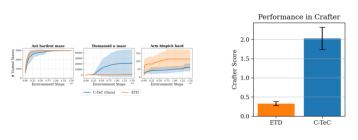

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
img1 = mpimg.imread("robot_envs.png")
img2 = mpimg.imread("Crafter_etd_ctec.png")

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(8, ))  # adjust figsize as needed

# First image
axes[0].imshow(img1)
axes[0].axis("off")   # remove axes
# axes[0].set_title("Figure 1")

# Second image
axes[1].imshow(img2)
axes[1].axis("off")
# axes[1].set_title("Figure 2")

plt.tight_layout()
plt.show()